# Week 2 · Day 1 — 光谱指数分析与土壤侵蚀伪标签生成

**数据**：`../data/raw/hls_sample/` 中的独立波段 TIF 文件（B02~B12）  
**输出**：`../data/processed/week2_patches/` — 图像 patch + 掩码 npy 文件

| Index | 波段文件 | 物理意义 |
|-------|----------|----------|
| 0 | B02.tif | Blue 490nm |
| 1 | B03.tif | Green 560nm |
| 2 | B04.tif | Red 665nm |
| 3 | B8A.tif | NIR 865nm |
| 4 | B11.tif | SWIR1 1610nm |
| 5 | B12.tif | SWIR2 2190nm |

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False

import numpy as np
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

# ── 路径（与 Week 1 保持一致，相对 notebooks/ 目录）────────────
DATA_DIR   = Path('../data/raw/hls_sample')        # 独立波段 TIF
PATCH_DIR  = Path('../data/processed/week2_patches')
FIG_DIR    = Path('../results/figures')
PATCH_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Week 1 确认的波段顺序和文件名
BANDS = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

# Week 1 使用的归一化参数（来自 notebook 04）
MEAN = np.array([343.4, 546.8, 444.1, 2942.5, 1444.6, 899.7], dtype=np.float32)
STD  = np.array([255.0, 340.6, 373.0, 1232.4,  852.0, 680.1], dtype=np.float32)

# 检查文件是否存在
for band in BANDS:
    p = DATA_DIR / f'{band}.tif'
    status = '✓' if p.exists() else '✗ 缺失'
    print(f'  {band}.tif  {status}')

  B02.tif  ✓
  B03.tif  ✓
  B04.tif  ✓
  B8A.tif  ✓
  B11.tif  ✓
  B12.tif  ✓


## 1.1 读取全幅影像（3660×3660）

In [3]:
def read_band(band_name):
    """读取单个波段，返回 (H, W) float32，nodata→0"""
    with rasterio.open(DATA_DIR / f'{band_name}.tif') as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return np.nan_to_num(arr, nan=0.0)

def load_full_image():
    """加载全部6波段，返回 (6, H, W) float32，原始 DN 值"""
    return np.stack([read_band(b) for b in BANDS], axis=0)

print('正在读取全幅影像（约 3660×3660）...')
full_img = load_full_image()  # (6, H, W)
H, W = full_img.shape[1], full_img.shape[2]

print(f'\n全幅影像形状: {full_img.shape}')
print(f'空间尺寸:    {H} × {W} 像素（30m 分辨率 → {H*30/1000:.0f}km × {W*30/1000:.0f}km）')
print(f'\n{"波段":<8} {"Min":>8} {"Max":>8} {"Mean":>8}')
print('-' * 36)
for i, b in enumerate(BANDS):
    arr = full_img[i]
    print(f'{b:<8} {arr.min():>8.0f} {arr.max():>8.0f} {arr.mean():>8.0f}')

正在读取全幅影像（约 3660×3660）...

全幅影像形状: (6, 3660, 3660)
空间尺寸:    3660 × 3660 像素（30m 分辨率 → 110km × 110km）

波段            Min      Max     Mean
------------------------------------
B02         -1991    14187     1417
B03         -1963    14445     1566
B04         -1861    14647     1627
B8A         -1469    15739     3095
B11          -286    13312     2023
B12           -85    15093     1665


## 1.2 计算光谱指数（基于原始 DN 值）

- **NDVI** = (B8A − B04) / (B8A + B04)：低值 = 裸土/侵蚀
- **NDWI** = (B03 − B8A) / (B03 + B8A)：高值 = 水体
- **BSI**  = ((B11+B04) − (B8A+B02)) / ((B11+B04) + (B8A+B02))：高值 = 裸土

In [4]:
eps = 1e-6
blue, green, red, nir, swir1 = (full_img[0], full_img[1],
                                 full_img[2], full_img[3], full_img[4])

ndvi = (nir  - red)   / (nir  + red   + eps)
ndwi = (green - nir)  / (green + nir  + eps)
bsi  = ((swir1+red) - (nir+blue)) / ((swir1+red) + (nir+blue) + eps)

for name, arr in [('NDVI', ndvi), ('NDWI', ndwi), ('BSI', bsi)]:
    print(f'{name}  min={arr.min():.3f}  max={arr.max():.3f}  mean={arr.mean():.3f}')

# ── RGB 可视化辅助函数 ────────────────────────────────────────
def make_rgb(img_6band, p_low=2, p_high=98):
    """(6,H,W) → (H,W,3) 归一化 RGB，取 B04=红 B03=绿 B02=蓝"""
    rgb = img_6band[[2, 1, 0]].copy().astype(np.float32)
    for i in range(3):
        lo, hi = np.percentile(rgb[i], [p_low, p_high])
        rgb[i] = np.clip((rgb[i] - lo) / (hi - lo + 1e-8), 0, 1)
    return rgb.transpose(1, 2, 0)

NDVI  min=-656000000.000  max=1796000000.000  mean=10349.923
NDWI  min=-2812000000.000  max=950000000.000  mean=-17427.180
BSI  min=-1196000000.000  max=2576000000.000  mean=6498.748


In [ ]:
# 中心区域裁剪预览（避免显示 3660px 全图太慢）
cy, cx = H // 2, W // 2
PREVIEW = 512
sl = (slice(cy-PREVIEW//2, cy+PREVIEW//2),
      slice(cx-PREVIEW//2, cx+PREVIEW//2))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(make_rgb(full_img[:, sl[0], sl[1]]))
axes[0].set_title('RGB 真彩色')

for ax, arr, title, cmap, vmin, vmax in [
    (axes[1], ndvi[sl], 'NDVI（绿=植被）',  'RdYlGn', -0.3, 0.7),
    (axes[2], ndwi[sl], 'NDWI（蓝=水体）',  'Blues',  -0.4, 0.4),
    (axes[3], bsi[sl],  'BSI（红=裸土）',   'OrRd',   -0.3, 0.5),
]:
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

for ax in axes: ax.axis('off')
plt.suptitle('悉尼 HLS Sentinel-2 · 中心 512×512 区域预览', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week2_05_spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

## 1.3 NDVI 直方图 → 确定阈值

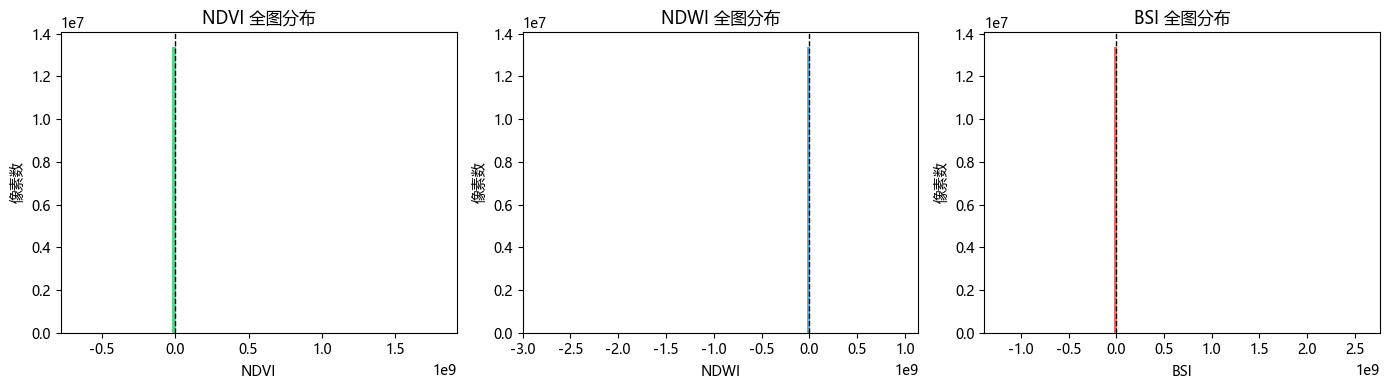

NDVI 分位数（用于选择侵蚀阈值）:
  P 5 = -0.089
  P10 = 0.000
  P25 = 0.124
  P50 = 0.428
  P75 = 0.690


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, arr, name, color in zip(
    axes, [ndvi, ndwi, bsi], ['NDVI', 'NDWI', 'BSI'],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    ax.hist(arr.ravel(), bins=100, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0.0, color='black', linestyle='--', lw=1)
    ax.set_title(f'{name} 全图分布')
    ax.set_xlabel(name); ax.set_ylabel('像素数')
plt.tight_layout(); plt.show()

print('NDVI 分位数（用于选择侵蚀阈值）:')
for q in [5, 10, 25, 50, 75]:
    print(f'  P{q:2d} = {np.percentile(ndvi, q):.3f}')

## 1.4 生成 patch + 伪标签

从 3660×3660 全图中**随机采样 224×224 patch**，同时生成侵蚀掩码。

侵蚀条件：`NDVI < 0.25` 且 `NDWI < 0.0`（低植被 + 非水体）

In [6]:
# ── 参数（可根据直方图调整）──────────────────────────────────
NDVI_THRESH     = 0.25
NDWI_THRESH     = 0.00
PATCH_SIZE      = 224
N_PATCHES       = 200    # 采样多少个 patch
MIN_EROSION_PCT = 0.05   # 侵蚀面积下限（过滤全黑）
MAX_EROSION_PCT = 0.90   # 侵蚀面积上限（过滤质量差）
np.random.seed(42)

P = PATCH_SIZE
erosion_map = ((ndvi < NDVI_THRESH) & (ndwi < NDWI_THRESH)).astype(np.uint8)
print(f'全图侵蚀占比: {erosion_map.mean():.3f}  ({erosion_map.mean()*100:.1f}%)')

saved, tried = 0, 0
pbar = tqdm(total=N_PATCHES, desc='采样 patch')

while saved < N_PATCHES and tried < N_PATCHES * 20:
    tried += 1
    y0 = np.random.randint(0, H - P)
    x0 = np.random.randint(0, W - P)

    mask_patch = erosion_map[y0:y0+P, x0:x0+P]
    pct = mask_patch.mean()
    if not (MIN_EROSION_PCT <= pct <= MAX_EROSION_PCT):
        continue

    img_patch = full_img[:, y0:y0+P, x0:x0+P].copy()   # (6,224,224) raw DN

    np.save(PATCH_DIR / f'img_{saved:04d}.npy',  img_patch)
    np.save(PATCH_DIR / f'mask_{saved:04d}.npy', mask_patch)
    saved += 1
    pbar.update(1)

pbar.close()
print(f'\n✓ 保存了 {saved} 个 patch（尝试 {tried} 次）')
print(f'  路径: {PATCH_DIR}')

全图侵蚀占比: 0.232  (23.2%)


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

## 1.5 可视化：patch + 掩码质量检查

In [ ]:
import matplotlib.colors as mcolors
cmap_e = mcolors.ListedColormap(['#1a1a2e', '#e94560'])

n_show = min(4, saved)
fig, axes = plt.subplots(n_show, 3, figsize=(11, 4*n_show))
if n_show == 1: axes = axes[None, :]

for i in range(n_show):
    img_p  = np.load(PATCH_DIR / f'img_{i:04d}.npy')   # (6,224,224)
    mask_p = np.load(PATCH_DIR / f'mask_{i:04d}.npy')  # (224,224)

    # NDVI for this patch
    nir_p = img_p[3]; red_p = img_p[2]
    ndvi_p = (nir_p - red_p) / (nir_p + red_p + 1e-6)

    axes[i,0].imshow(make_rgb(img_p))
    axes[i,0].set_title(f'RGB  patch #{i}'); axes[i,0].axis('off')

    axes[i,1].imshow(ndvi_p, cmap='RdYlGn', vmin=-0.3, vmax=0.7)
    axes[i,1].set_title('NDVI'); axes[i,1].axis('off')

    axes[i,2].imshow(mask_p, cmap=cmap_e, vmin=0, vmax=1)
    axes[i,2].set_title(f'侵蚀掩码  ({mask_p.mean():.2%})'); axes[i,2].axis('off')

plt.suptitle('伪标签质量检查', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week2_05_label_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Day 1 完成')

---
## 💾 保存到 GitHub

In [ ]:
import subprocess, os

# 仓库根目录（notebooks 的上一级）
REPO_DIR = str(Path('..').resolve())
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)
    return r.returncode

print('── git status ──')
git('git status --short')

In [ ]:
git('git add notebooks/05_spectral_labels.ipynb')
git('git add results/figures/week2_05_spectral_indices.png')
git('git add results/figures/week2_05_label_check.png')
# .npy patch 文件较大，由 .gitignore 排除，不推送

git('git commit -m "Week2 Day1: spectral indices (NDVI/NDWI/BSI) + pseudo label patches generated"')
git('git push origin main')
print('\n✓ 已推送到 https://github.com/lofophil/geo-foundation-experiments')